Import libraries
===

In [542]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix

Load cricket dataset
===

In [543]:
df = pd.read_csv("../data/raw/IPL_B2B_Dataset.csv")

C:\Users\adity\AppData\Local\Temp\ipykernel_24480\2941741668.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/raw/IPL_B2B_Dataset.csv")


Initial Data Inspection
===

In [544]:
df.head()

,Index,batting_team,bowling_team,city,runs_left,balls_left,wickets,target_runs,cur_run_rate,req_run_rate,result,Unnamed: 11,Unnamed: 12
0,0,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,119,10,208,6.0,10.43697479,0,NaN,NaN
1,1,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,118,10,208,3.0,10.52542373,0,NaN,NaN
2,2,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,207,117,10,208,2.0,10.61538462,0,NaN,NaN
3,3,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,205,116,10,208,4.5,10.60344828,0,NaN,NaN
4,4,Royal Challengers Bangalore,Sunrisers Hyderabad,Hyderabad,201,115,10,208,8.4,10.48695652,0,NaN,NaN


In [545]:
df.tail()

,Index,batting_team,bowling_team,city,runs_left,balls_left,wickets,target_runs,cur_run_rate,req_run_rate,result,Unnamed: 11,Unnamed: 12
72408,72408,Chennai Super Kings,Mumbai Indians,Hyderabad,1,4,5,153,7.862069,1.5,0,NaN,NaN
72409,72409,Chennai Super Kings,Mumbai Indians,Hyderabad,-1,3,5,153,7.897436,-2,0,NaN,NaN
72410,72410,Chennai Super Kings,Mumbai Indians,Hyderabad,-2,2,4,153,7.881356,-6,0,NaN,NaN
72411,72411,Chennai Super Kings,Mumbai Indians,Hyderabad,-4,1,4,153,7.915966,-24,0,NaN,NaN
72412,72412,Chennai Super Kings,Mumbai Indians,Hyderabad,-4,0,3,153,7.850000,#NAME?,0,NaN,NaN


In [546]:
df.columns

Index(['Index', 'batting_team', 'bowling_team', 'city', 'runs_left',
       'balls_left', 'wickets', 'target_runs', 'cur_run_rate', 'req_run_rate',
       'result', 'Unnamed: 11', 'Unnamed: 12'],
      dtype='object')

In [547]:
df.columns.tolist()

['Index',
 'batting_team',
 'bowling_team',
 'city',
 'runs_left',
 'balls_left',
 'wickets',
 'target_runs',
 'cur_run_rate',
 'req_run_rate',
 'result',
 'Unnamed: 11',
 'Unnamed: 12']

In [548]:
df.shape

(72413, 13)

In [549]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72413 entries, 0 to 72412
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Index         72413 non-null  int64  
 1   batting_team  72413 non-null  object 
 2   bowling_team  72413 non-null  object 
 3   city          71581 non-null  object 
 4   runs_left     72413 non-null  int64  
 5   balls_left    72413 non-null  int64  
 6   wickets       72413 non-null  int64  
 7   target_runs   72413 non-null  int64  
 8   cur_run_rate  72413 non-null  float64
 9   req_run_rate  72408 non-null  object 
 10  result        72413 non-null  int64  
 11  Unnamed: 11   0 non-null      float64
 12  Unnamed: 12   1 non-null      object 
dtypes: float64(2), int64(6), object(5)
memory usage: 7.2+ MB


In [550]:
df.describe()

,Index,runs_left,balls_left,wickets,target_runs,cur_run_rate,result,Unnamed: 11
count,72413.000000,72413.000000,72413.000000,72413.000000,72413.000000,72413.000000,72413.000000,0.0
mean,36206.000000,93.258379,62.657078,7.535967,166.583956,7.439523,0.525624,NaN
std,20903.976858,50.021962,33.404593,2.138637,29.282200,2.275850,0.499346,NaN
min,0.000000,-15.000000,-2.000000,0.000000,66.000000,0.000000,0.000000,NaN
25%,18103.000000,54.000000,35.000000,6.000000,147.000000,6.257143,0.000000,NaN
50%,36206.000000,93.000000,63.000000,8.000000,166.000000,7.480519,1.000000,NaN
75%,54309.000000,131.000000,92.000000,9.000000,186.000000,8.682353,1.000000,NaN
max,72412.000000,250.000000,119.000000,10.000000,251.000000,42.000000,1.000000,NaN


Data Cleaning / Quality
===

In [551]:
df['req_run_rate'] = pd.to_numeric(
    df['req_run_rate'],
    errors='coerce'
)

In [552]:
df['req_run_rate'].isnull().sum()

np.int64(18)

In [553]:
df = df.drop(columns=['Unnamed: 11', 'Unnamed: 12'])
df = df.drop(columns=['Index'])

In [554]:
df.isnull().sum()

batting_team      0
bowling_team      0
city            832
runs_left         0
balls_left        0
wickets           0
target_runs       0
cur_run_rate      0
req_run_rate     18
result            0
dtype: int64

In [555]:
df.isnull().sum().sort_values(ascending = False)

city            832
req_run_rate     18
bowling_team      0
batting_team      0
balls_left        0
runs_left         0
wickets           0
target_runs       0
cur_run_rate      0
result            0
dtype: int64

In [556]:
missing_percentage = (df.isnull().sum() / len(df) * 100).sort_values(ascending = False)
missing_percentage

city            1.148965
req_run_rate    0.024857
bowling_team    0.000000
batting_team    0.000000
balls_left      0.000000
runs_left       0.000000
wickets         0.000000
target_runs     0.000000
cur_run_rate    0.000000
result          0.000000
dtype: float64

In [557]:
df.duplicated().sum()

np.int64(580)

Target Analysis
===

In [558]:
df['result'].value_counts()

result
1    38062
0    34351
Name: count, dtype: int64

In [559]:
df['result'].value_counts(normalize = True)

result
1    0.525624
0    0.474376
Name: proportion, dtype: float64

Exploratory Data Analysis
===

### Match Outcome Distribution

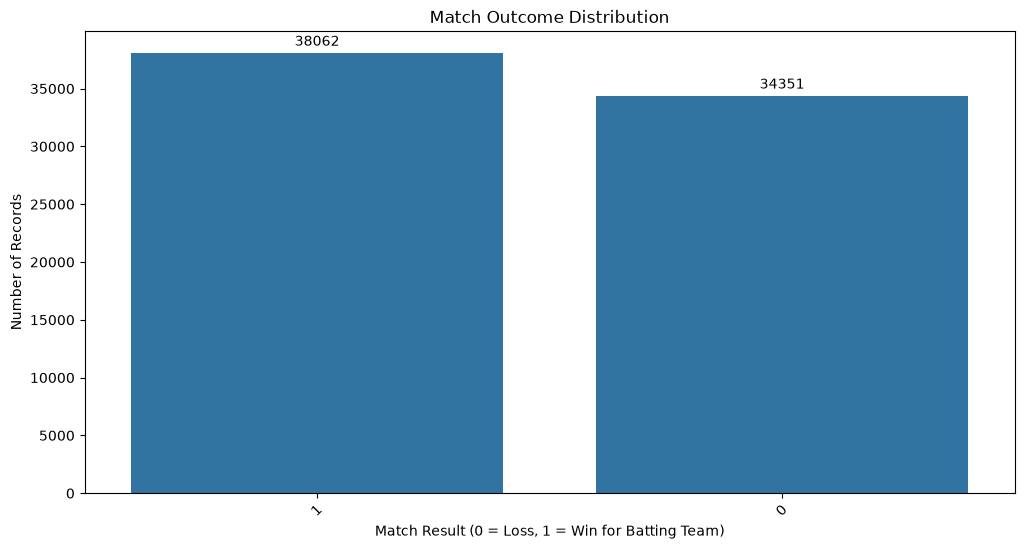

In [560]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data = df, x = 'result', order = df['result'].value_counts().index)

for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title('Match Outcome Distribution')

plt.xlabel(
    'Match Result (0 = Loss, 1 = Win for Batting Team)'
)

plt.ylabel('Number of Records')
plt.xticks(rotation=45)

plt.show()

### Venue

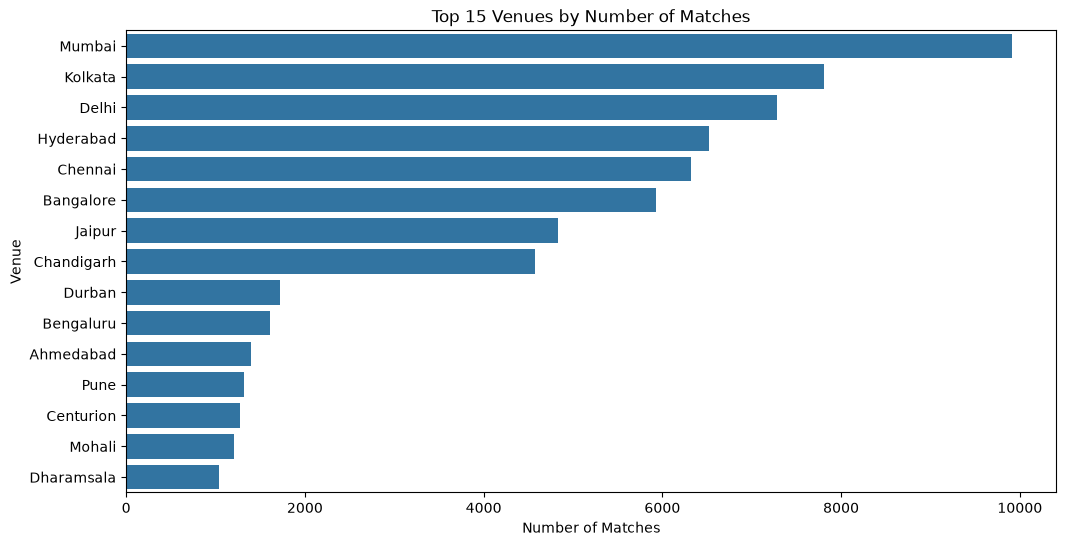

In [561]:
venue_counts = df['city'].value_counts().head(15)

plt.figure(figsize = (12, 6))

sns.barplot(x = venue_counts.values, y = venue_counts.index)

plt.title('Top 15 Venues by Number of Matches')
plt.xlabel('Number of Matches')
plt.ylabel('Venue')

plt.show()

In [562]:
df[['batting_team', 'bowling_team', 'result']].head(20)

,batting_team,bowling_team,result
0,Royal Challengers Bangalore,Sunrisers Hyderabad,0
1,Royal Challengers Bangalore,Sunrisers Hyderabad,0
2,Royal Challengers Bangalore,Sunrisers Hyderabad,0
3,Royal Challengers Bangalore,Sunrisers Hyderabad,0
4,Royal Challengers Bangalore,Sunrisers Hyderabad,0
5,Royal Challengers Bangalore,Sunrisers Hyderabad,0
6,Royal Challengers Bangalore,Sunrisers Hyderabad,0
7,Royal Challengers Bangalore,Sunrisers Hyderabad,0
8,Royal Challengers Bangalore,Sunrisers Hyderabad,0
9,Royal Challengers Bangalore,Sunrisers Hyderabad,0


Feature Selection
===

In [563]:
features = [
    'batting_team',
    'bowling_team',
    'city',
    'runs_left',
    'balls_left',
    'wickets',
    'target_runs',
    'cur_run_rate',
    'req_run_rate'
]

target = 'result'

Baseline Data Cleaning
===

In [564]:
# Data cleaning for baseline model
df_baseline = df.copy()

# Replace infinite values with NaN
df_baseline = df_baseline.replace([np.inf, -np.inf], np.nan)

# Remove invalid/terminal match states
df_baseline = df_baseline[
    (df_baseline['balls_left'] > 0) &
    (df_baseline['runs_left'] > 0)
].copy()

# Handle missing categorical values
df_baseline['city'] = df_baseline['city'].fillna('Unknown')

# Handle missing numerical values
df_baseline['req_run_rate'] = df_baseline['req_run_rate'].fillna(
    df_baseline['req_run_rate'].median()
)

print("Remaining missing values:")
print(df_baseline.isnull().sum())

Remaining missing values:
batting_team    0
bowling_team    0
city            0
runs_left       0
balls_left      0
wickets         0
target_runs     0
cur_run_rate    0
req_run_rate    0
result          0
dtype: int64


In [565]:
print("Dataset shape after cleaning:", df_baseline.shape)

Dataset shape after cleaning: (71741, 10)


Encode categorical columns
===

In [566]:
le = LabelEncoder()

for col in df_baseline[features + [target]].select_dtypes(
    include='object'
).columns:
    df_baseline[col] = le.fit_transform(
        df_baseline[col].astype(str)
    )

In [567]:
df_baseline.head()

,batting_team,bowling_team,city,runs_left,balls_left,wickets,target_runs,cur_run_rate,req_run_rate,result
0,8,9,14,207,119,10,208,6.0,10.436975,0
1,8,9,14,207,118,10,208,3.0,10.525424,0
2,8,9,14,207,117,10,208,2.0,10.615385,0
3,8,9,14,205,116,10,208,4.5,10.603448,0
4,8,9,14,201,115,10,208,8.4,10.486957,0


Create X and y
===

In [568]:
X = df_baseline[features]
y = df_baseline[target]

In [569]:
X.head()

,batting_team,bowling_team,city,runs_left,balls_left,wickets,target_runs,cur_run_rate,req_run_rate
0,8,9,14,207,119,10,208,6.0,10.436975
1,8,9,14,207,118,10,208,3.0,10.525424
2,8,9,14,207,117,10,208,2.0,10.615385
3,8,9,14,205,116,10,208,4.5,10.603448
4,8,9,14,201,115,10,208,8.4,10.486957


In [570]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: result, dtype: int64

In [571]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (71741, 9)
y shape: (71741,)


Train/test split
===

In [572]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [573]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (57392, 9)
Testing data: (14349, 9)


Logistic Regression Baseline
===

In [574]:
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Predictions
===

In [575]:
y_pred = model.predict(X_test)

y_proba = model.predict_proba(X_test)[:, 1]

Accuracy
===

In [576]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Baseline Accuracy: {accuracy:.4f}")

Baseline Accuracy: 0.7697


ROC-AUC
===

In [577]:
auc = roc_auc_score(y_test, y_proba)
print(f"Baseline ROC-AUC: {auc:.4f}")

Baseline ROC-AUC: 0.8644


Classification Report
===

In [578]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.74      0.75      6815
           1       0.77      0.80      0.78      7534

    accuracy                           0.77     14349
   macro avg       0.77      0.77      0.77     14349
weighted avg       0.77      0.77      0.77     14349



Confusion Matrix
===

In [579]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[5030 1785]
 [1519 6015]]


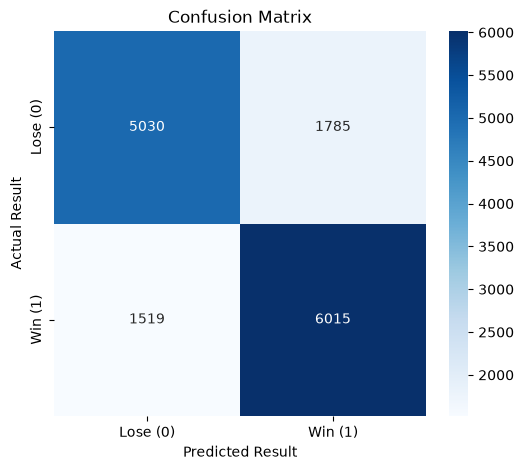

In [580]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Lose (0)', 'Win (1)'],
    yticklabels=['Lose (0)', 'Win (1)']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Result')
plt.ylabel('Actual Result')

plt.show()

Final Baseline Results
===

In [581]:
print("===== BASELINE MODEL RESULTS =====")
print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {auc:.4f}")

===== BASELINE MODEL RESULTS =====
Accuracy : 0.7697
ROC-AUC  : 0.8644


## Data Story

The Cricket Match Outcome dataset contains live match-state information that can be used to predict whether the batting team will win or lose.

The target variable `result` is binary, where `0` represents a loss for the batting team and `1` represents a win. The target distribution is reasonably balanced, with both classes having a substantial number of records.

The exploratory analysis shows that the dataset contains important match-state variables such as runs remaining, balls remaining, wickets, current run rate, required run rate, batting team, bowling team, and venue.

During data quality analysis, missing values were identified in `city` and `req_run_rate`. Infinite values and invalid terminal match states were also handled before model training. This was necessary because Logistic Regression cannot directly process missing or infinite values.

A Logistic Regression model was used as the initial classification baseline. Accuracy and ROC-AUC were selected as the primary evaluation metrics, while the classification report and confusion matrix were used to understand the model's prediction performance for both outcome classes.

This baseline provides a starting point for the project. In later stages, the model can be improved using a more robust preprocessing pipeline, better categorical encoding, feature engineering, and comparison with more advanced classification algorithms.